In [1]:
!pip install flat

In [2]:
from flat import document, shape, rgba
from IPython.display import SVG, display
from ipywidgets import widgets

def show(page):
    display(SVG(page.svg()))

In [3]:
!pip install https://github.com/aparrish/bezmerizing/archive/master.zip

  Using cached https://github.com/aparrish/bezmerizing/archive/master.zip
  Created wheel for bezmerizing: filename=bezmerizing-0.1.1-py3-none-any.whl size=17284 sha256=aebc16326e990638717078c26a4c15d88c888d1256380da3397b3e5f1398fec7
  Stored in directory: /private/var/folders/3v/lxt4vwb95zs2ttfnbk5g_pch0000gn/T/pip-ephem-wheel-cache-vue2k8vh/wheels/74/5a/7d/4a62c2490b6c6061916e41ae070caaed12664893aef1a56d7c
Successfully built bezmerizing


In [4]:
from bezmerizing import Polyline
import numpy as np
from numpy.random import uniform, normal, choice

In [71]:
textWidget = widgets.Text(
    value='',
    placeholder='Type something',
    description='Text to siggify:',
    disabled=False
)

randWidget = widgets.IntSlider(
    value=0,
    width=200,
    min=0,
    max=100,
    step=1,
    description='Randomness:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)


# Interactive sigGenerator with widgets!

#### Give me some information please!

In [74]:
textWidget

Text(value='', description='Text to siggify:', placeholder='Type something')

In [72]:
randWidget

IntSlider(value=0, continuous_update=False, description='Randomness:')

In [75]:
# convert inputted text into letter height values


shortLetters = "acemnorsuvwxz"
medLetters = "bdfhklt"
underLetters = "gjpqy"
tallLetters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ1234567890"

#extracts some info from inputted information

textIn = str(textWidget.value)
attOffset = randWidget.value
letterHeight = heightWidget.value
print(attOffset)

letInfo = []

for letter in textIn:
    if letter in shortLetters:
        letInfo.append(0)
    elif letter in medLetters:
        letInfo.append(1)
    elif letter in underLetters:
        letInfo.append(2)
    elif letter in tallLetters:
        letInfo.append(3)
    

0


In [76]:
# 0: short, 1: medium, 2: under, 3: tall

# def makeDJTSig(length, height, options, probs, segs):
def interactSig(text, segWidth, height, options, attOffset):
    pts = []
    pts.append([0,height])
    pts.append([0,height])
    for let in range(len(letInfo)): # for each letter:
        #add stroke going up (2 strokes for tall letters/numbers)
        x = segWidth*let+segWidth/2+uniform(attOffset*-1, attOffset)
        y = options[letInfo[let]]+uniform(attOffset*-1, attOffset)
        if letInfo[let] == 3:
            x2 = uniform(x-segWidth, x+segWidth)+uniform(attOffset*-1, attOffset)
            y2 = uniform(height*.3,height*.8)+uniform(attOffset*-1, attOffset)
            pts.append([x2,y2])
        y = uniform(y-3, y+3)+uniform(attOffset*-1, attOffset)
        pts.append([x,y])
        
        ##add stroke going down
        x = segWidth*let+segWidth
        if letInfo[let] == 3: #if letter is tall, adds a subsegment
            x2 = uniform(x-segWidth*2, x+segWidth*2)+uniform(attOffset*-1, attOffset)
            y = uniform(height*.3,height*.8)+uniform(attOffset*-1, attOffset)
            x = uniform(x2-segWidth, x2+segWidth)+uniform(attOffset*-1, attOffset)
            pts.append([x,y])
            pts.append([x2,height])
        if letInfo[let] == 2: # if letter is under
            y = height+(height-options[0])+uniform(attOffset*-1, attOffset)
        else:
            y = height+uniform(attOffset*-1, attOffset)
        pts.append([x-3, y])
        
    return Polyline(pts)
        


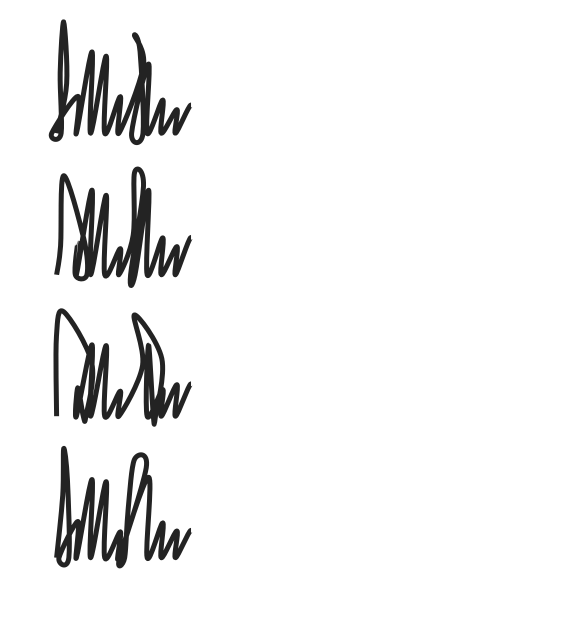

In [77]:
d = document(200,220,'mm')
page = d.addpage()
for s in range(4):
    lineTex = shape().stroke(rgba(0, 0, 0, 220)).width(5).join('round')
    myZig = interactSig(textIn, 5, 50, [39, 23, 39, 13], attOffset)
    zigShape = lineTex.path(myZig.smooth_path().translate(20,50*s-3))
    page.place(zigShape)
show(page)
